In [ ]:
%pip install streamlit

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
import pickle
import plotly.express as px
import streamlit as st
from sklearn.preprocessing import MinMaxScaler

raw = pd.read_csv("/Users/tanuridinethra/Desktop/Y3-S1/FDM/Churn-Prediction-System-dev-rajinda/Churn_Modelling.csv")

raw.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42.0,2,0.00,1,1.0,1.0,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41.0,1,83807.86,1,0.0,1.0,112542.58,0
2,3,15619304,Onio,502,France,Female,42.0,8,159660.80,3,1.0,0.0,113931.57,1
3,4,15701354,Boni,699,France,Female,39.0,1,0.00,2,0.0,0.0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43.0,2,125510.82,1,NaN,1.0,79084.10,0


# Data Pre-processing

In [ ]:

# Drop irrelevant columns
raw = raw.drop(["RowNumber", "CustomerId", "Surname"], axis=1)


### Understanding our data

In [4]:
for column in raw:
    # Check the data type of the column
    if raw[column].dtype in ['int64', 'float64']:
        # For numeric columns, fill missing values with a numeric placeholder (NaN)
        unique_vals = np.unique(raw[column].fillna(np.nan))
    else:
        # For non-numeric columns, fill missing values with a string placeholder
        unique_vals = np.unique(raw[column].fillna('Missing'))

    nr_values = len(unique_vals)
    if nr_values <= 12:
        print('The number of values for feature {} : {} - {}'.format(column, nr_values, unique_vals))
    else:
        print('The number of values for feature {} : {}'.format(column, nr_values))

The number of values for feature CreditScore : 460
The number of values for feature Geography : 4 - ['France' 'Germany' 'Missing' 'Spain']
The number of values for feature Gender : 2 - ['Female' 'Male']
The number of values for feature Age : 74
The number of values for feature Tenure : 11 - [ 0  1  2  3  4  5  6  7  8  9 10]
The number of values for feature Balance : 6382
The number of values for feature NumOfProducts : 4 - [1 2 3 4]
The number of values for feature HasCrCard : 3 - [ 0.  1. nan]
The number of values for feature IsActiveMember : 3 - [ 0.  1. nan]
The number of values for feature EstimatedSalary : 9999
The number of values for feature Exited : 2 - [0 1]


# Checking for null values

In [5]:
raw.isnull().sum()

CreditScore        0
Geography          1
Gender             0
Age                1
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          1
IsActiveMember     1
EstimatedSalary    0
Exited             0
dtype: int64

In [6]:
raw = raw.dropna(subset=["Geography"])

In [7]:
raw["Age"] = raw["Age"].fillna(raw["Age"].median())

In [49]:
print(raw[["HasCrCard", "NumOfProducts"]].isnull().sum())


HasCrCard        1
NumOfProducts    0
dtype: int64


In [9]:
#Use mode imputation (most common value, usually 1 because most customers have a card).
raw["HasCrCard"] = raw["HasCrCard"].fillna(raw["HasCrCard"].mode()[0])
raw["IsActiveMember"] = raw["IsActiveMember"].fillna(raw["IsActiveMember"].mode()[0])

# Visualizing the data

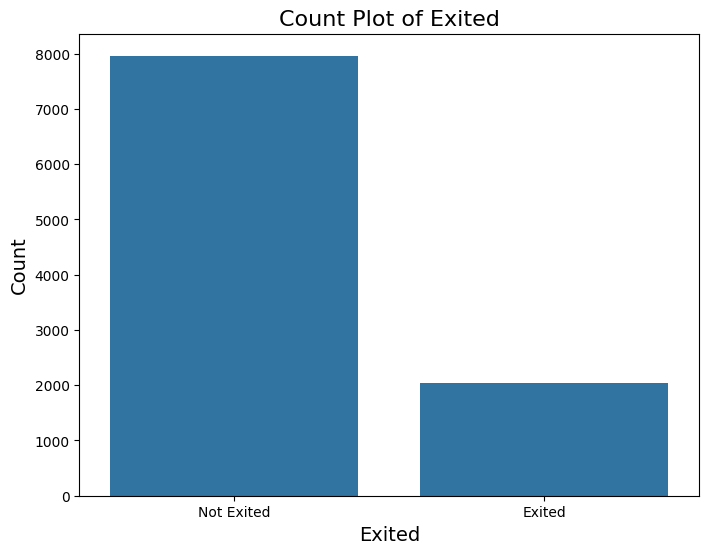

In [ ]:
#Count Plot of our Y - Check the balance of the dataset(churned and nonchurned customers are bakanced)
plt.figure(figsize=(8,6))
sns.countplot(data=raw, x='Exited') #check if the data is balanced
plt.title('Count Plot of Exited', fontsize=16)
plt.xlabel("Exited", fontsize=14)
plt.ylabel("Count", fontsize=14)
plt.xticks([0,1], labels=["Not Exited", "Exited"])
plt.show()

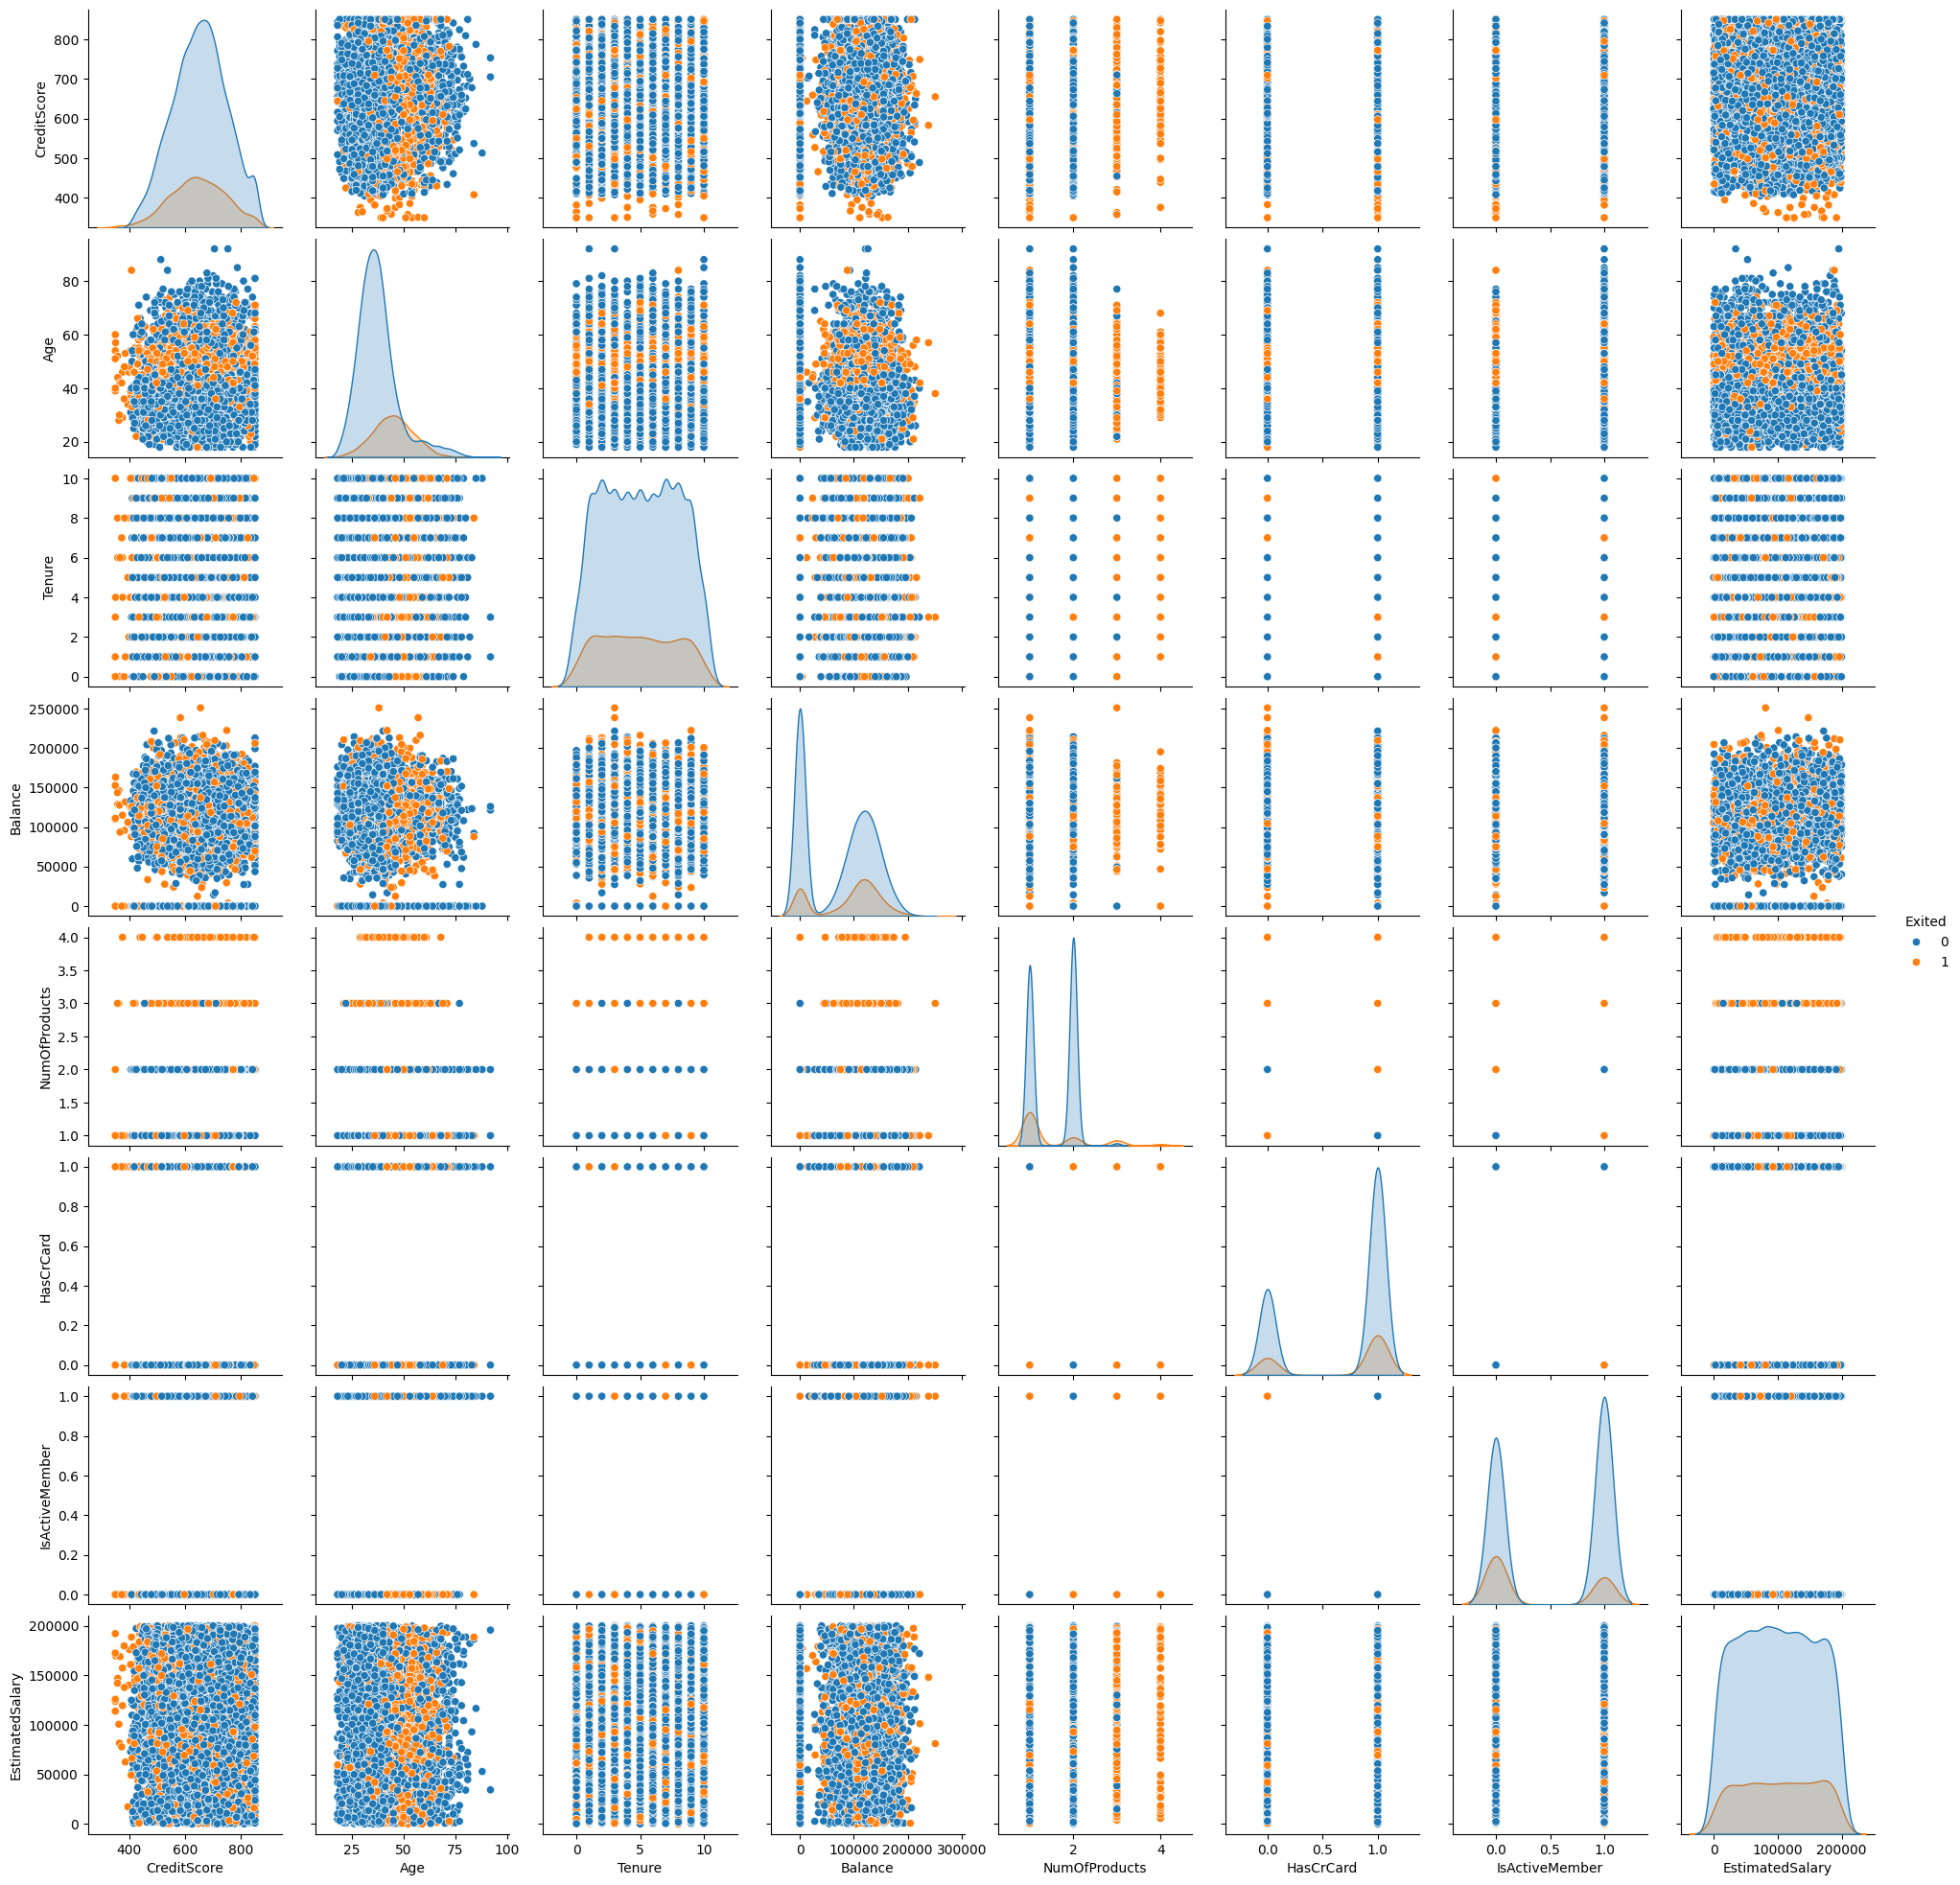

In [ ]:
#Limiting the data(visualize how features like age, balance, and tenure differ between churned and non-churned customers.)
raw_v = raw[['CreditScore', 'Geography', 'Gender', 'Age',
             'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
             'IsActiveMember', 'EstimatedSalary', 'Exited']]
g = sns.pairplot(raw_v, hue='Exited')

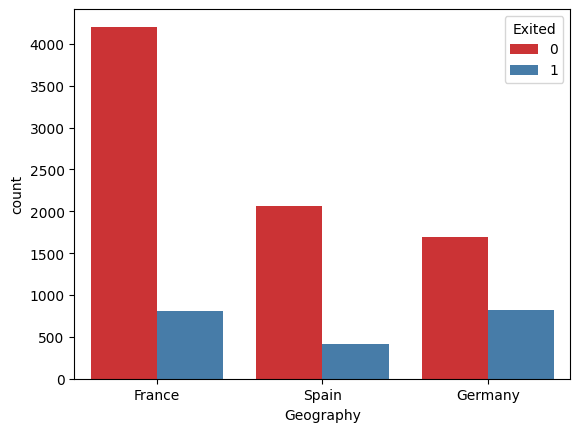

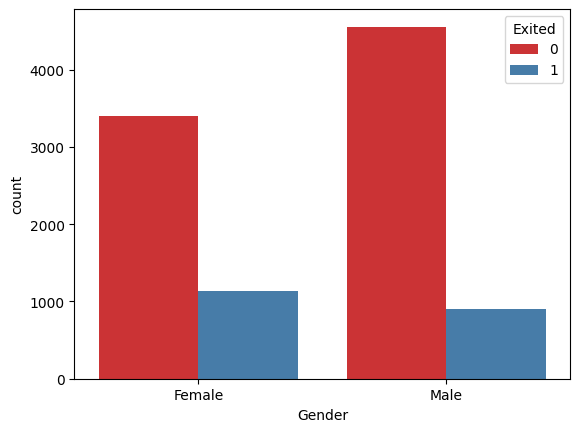

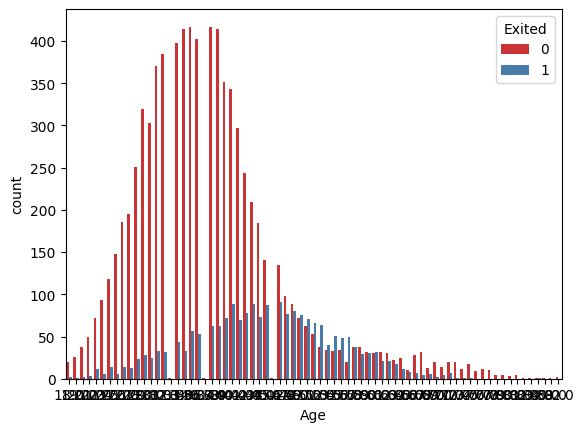

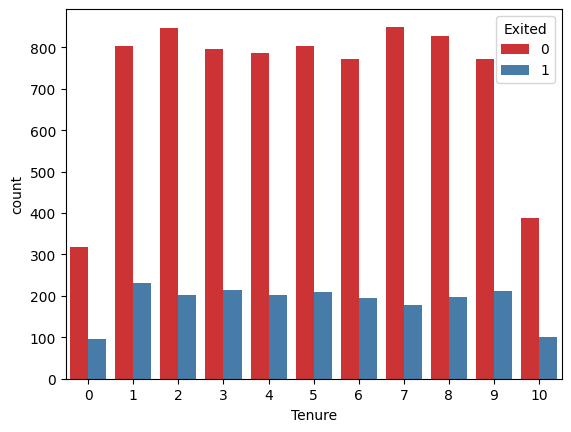

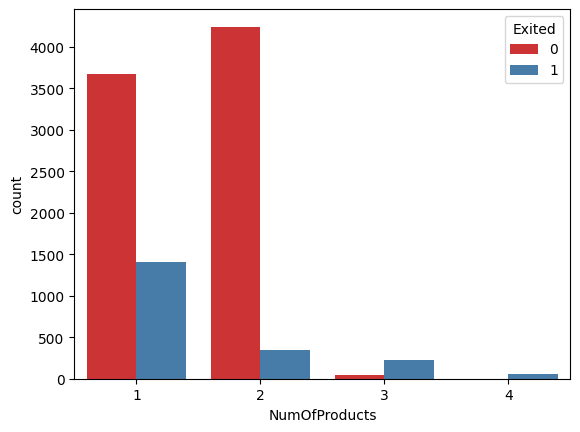

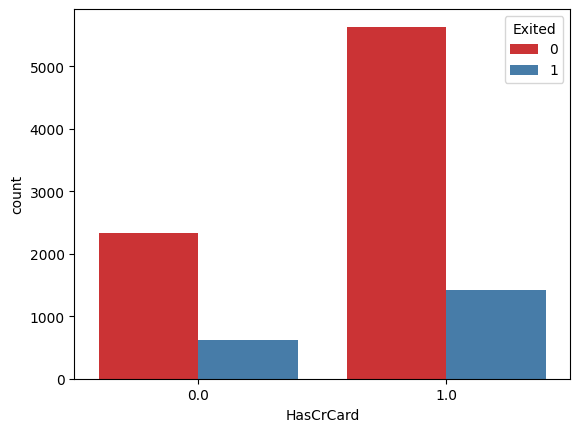

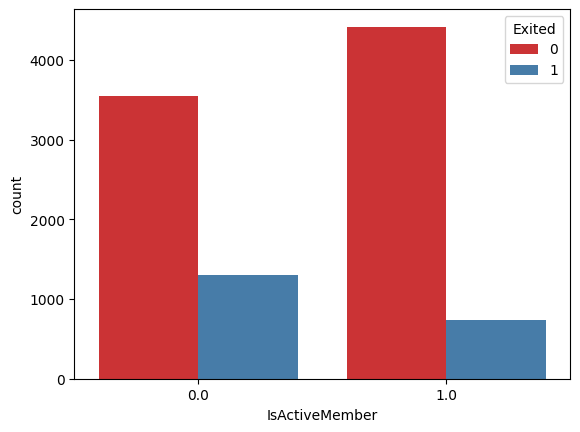

In [ ]:
#Investigate all the features by our y(compare churn vs non-churn distribution across features like geography, gender, and activity status)
features = ['Geography', 'Gender', 'Age', 'Tenure', 'NumOfProducts', 'HasCrCard', 'IsActiveMember']

for f in features:
  plt.figure()
  ax = sns.countplot(x=f, data=raw_v, hue='Exited', palette='Set1')

The median is:  652.0


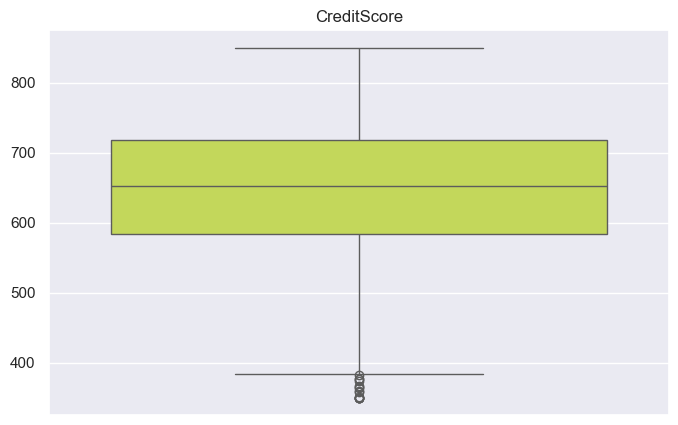

The median is:  37.0


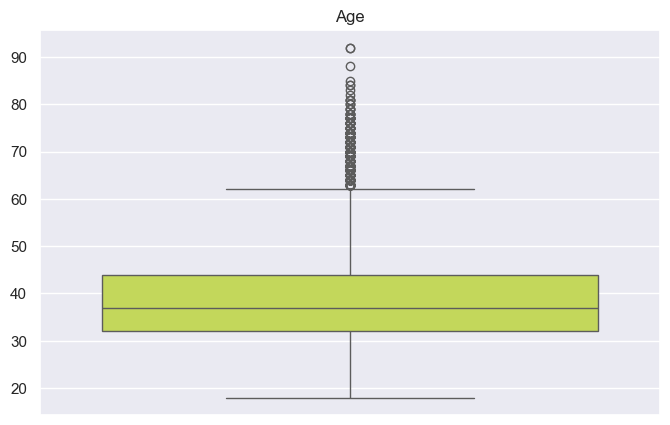

The median is:  5.0


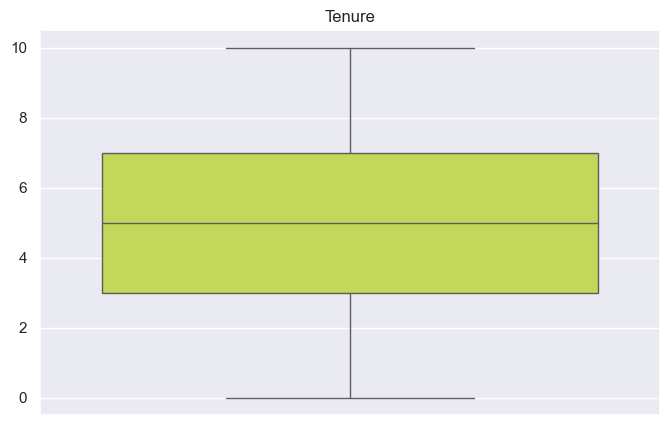

The median is:  97208.46


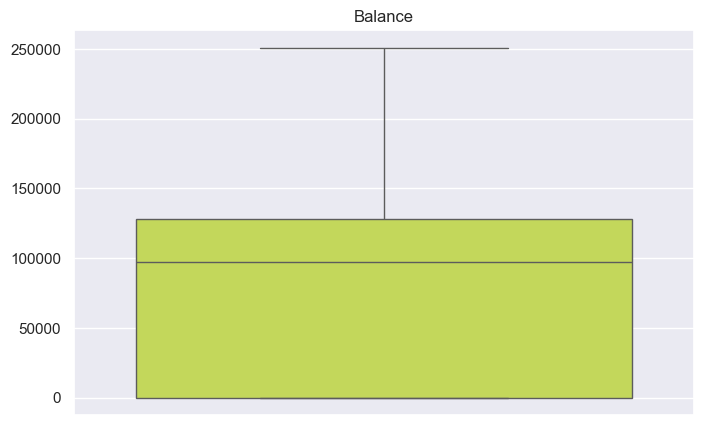

The median is:  1.0


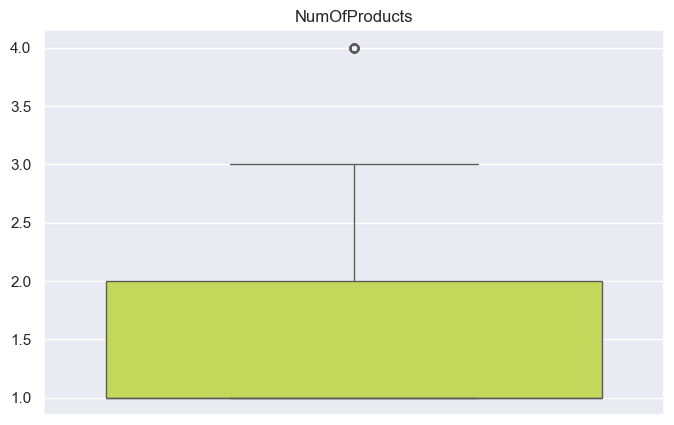

The median is:  1.0


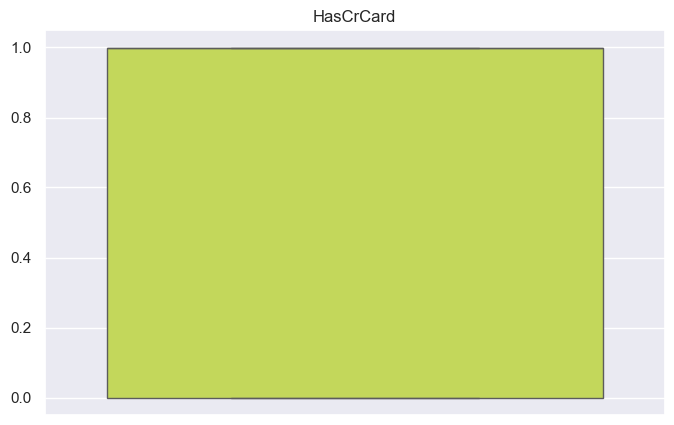

The median is:  1.0


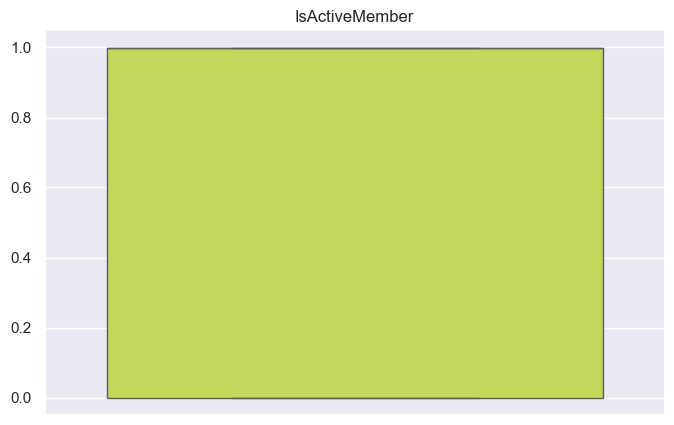

The median is:  100187.43


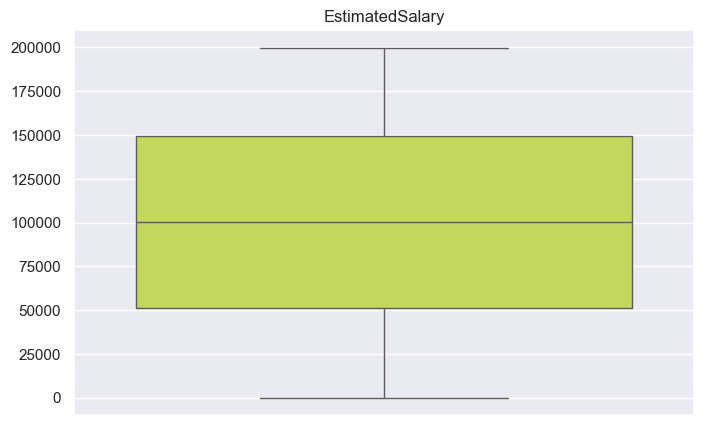

The median is:  0.0


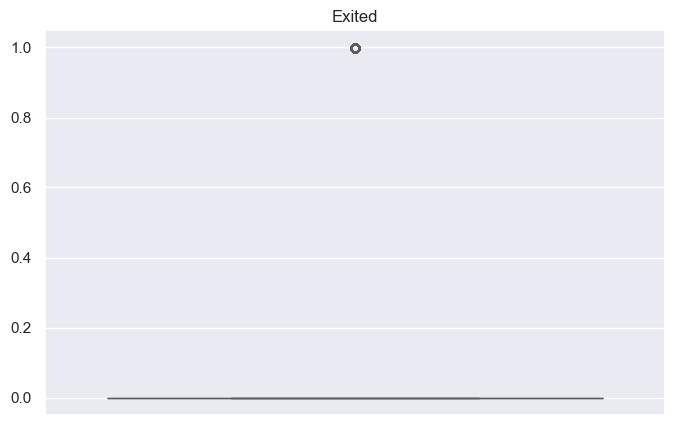

In [ ]:
#Investigating the distribution of all Numerical values(analyze numeric features like credit score, age, and salary to check for skewness and outliers)

#identifying all numeric columns
numerics = ['int16', 'int32', 'int64', 'float16', 'float32', 'float64']
n_variables = raw_v.select_dtypes(include=numerics).columns

sns.set(rc={'figure.figsize':(8,5)})

for c in n_variables:
  x = raw_v[c].values
  ax = sns.boxplot(x, color = '#D1EC46')
  print('The median is: ', raw_v[c].median())
  plt.title(c)
  plt.show()

# Preparing the final DF

In [ ]:
#making categorical variables into numeric representation for better model performance
new_raw_data = pd.get_dummies(raw_v, columns=['Geography', 'Gender', 'HasCrCard', 'IsActiveMember'])

#scaling the columns
scale_vars = ['CreditScore', 'EstimatedSalary', 'Tenure', 'Balance', 'Age', 'NumOfProducts']
scaler = MinMaxScaler()
new_raw_data[scale_vars] = scaler.fit_transform(new_raw_data[scale_vars])
new_raw_data.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,EstimatedSalary,Exited,Geography_France,Geography_Germany,Geography_Spain,Gender_Female,Gender_Male,HasCrCard_0.0,HasCrCard_1.0,IsActiveMember_0.0,IsActiveMember_1.0
0,0.538,0.324324,0.2,0.000000,0.000000,0.506735,1,True,False,False,True,False,False,True,False,True
1,0.516,0.310811,0.1,0.334031,0.000000,0.562709,0,False,False,True,True,False,True,False,False,True
2,0.304,0.324324,0.8,0.636357,0.666667,0.569654,1,True,False,False,True,False,False,True,True,False
3,0.698,0.283784,0.1,0.000000,0.333333,0.469120,0,True,False,False,True,False,True,False,True,False
4,1.000,0.337838,0.2,0.500246,0.000000,0.395400,0,False,False,True,True,False,False,True,False,True


# Running XGBoost

In [ ]:
#train an XGBoost model to predict customer churn and evaluate accuracy on both training and test data
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

#Features (X) and target (y)
X = new_raw_data.drop(columns=['Exited'])
y = new_raw_data['Exited']

#splitting the dataset into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#Initialize XGBoost classifier
model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
model.fit(X_train, y_train)

#Predictions
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

#Training and Testing Accuracy
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

print(f"Training Accuracy: {train_accuracy:.2f}")
print(f"Testing Accuracy: {test_accuracy:.2f}")

Training Accuracy: 0.96
Testing Accuracy: 0.86


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/xgboost/training.py:183: UserWarning: [12:41:05] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [16]:
#Feature Importance
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": model.feature_importances_
}).sort_values(by="Importance", ascending=False)

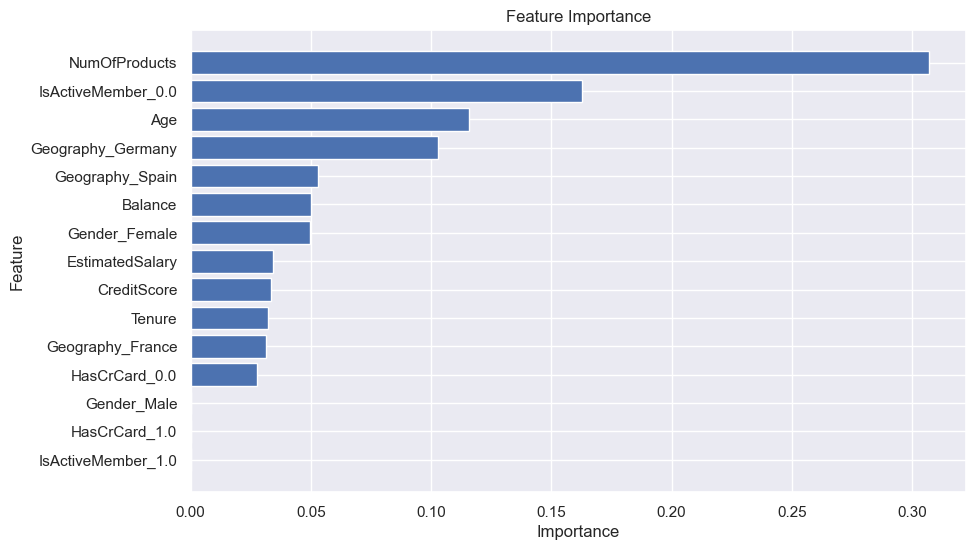


Feature Importance:


,Feature,Importance
4,NumOfProducts,0.306869
13,IsActiveMember_0.0,0.162825
1,Age,0.115654
7,Geography_Germany,0.102749
8,Geography_Spain,0.052907
3,Balance,0.050188
9,Gender_Female,0.049834
5,EstimatedSalary,0.034215
0,CreditScore,0.033476
2,Tenure,0.032367


In [17]:
#plotting feature importance
plt.figure(figsize=(10,6))
plt.barh(feature_importance["Feature"], feature_importance["Importance"], align='center')
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Feature Importance")
plt.gca().invert_yaxis()
plt.show()

print("\nFeature Importance:")
feature_importance

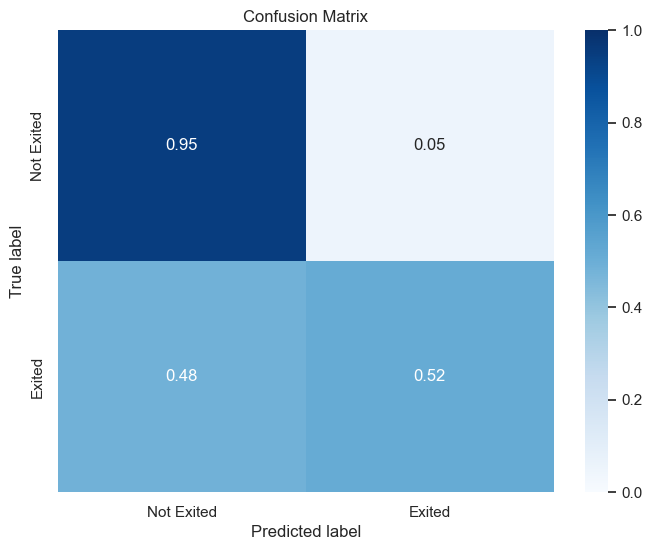

In [ ]:
# Confusion Matrix function(use a confusion matrix to see where the model is making errors — especially in predicting churned customers.)
def plot_confusion_matrix(cm, classes=None, title='Confusion Matrix'):
    """Plots a confusion matrix."""
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, xticklabels=classes, yticklabels=classes, vmin=0, vmax=1, annot=True, cmap="Blues", fmt='.2f')
    plt.title(title)
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.show()

# Calculate confusion matrix
cm = confusion_matrix(y_test, y_test_pred, normalize='true')
plot_confusion_matrix(cm, classes=["Not Exited", "Exited"])

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/xgboost/training.py:183: UserWarning: [12:42:32] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Training Accuracy: 0.96
Testing Accuracy: 0.86


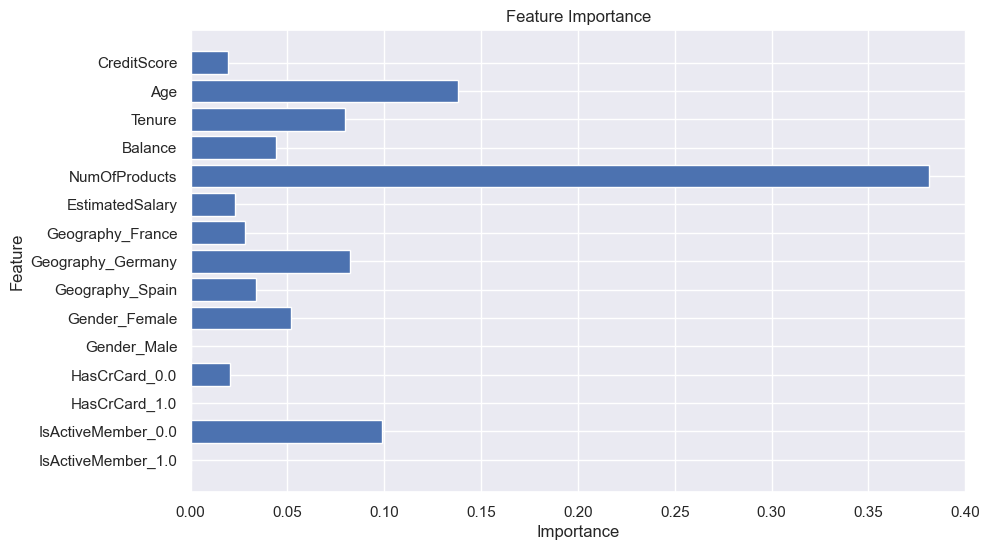

In [ ]:
# Running XGBoost using SMOTE(fix imbalance, we oversample churn cases using SMOTE and retrain the model for better predictions.)

from imblearn.over_sampling import SMOTE
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

# Applying SMOTE to oversample the minority class in the training set
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# Initialize the XGBoost classifier
model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
model.fit(X_train_resampled, y_train_resampled)

# Predictions
y_train_pred = model.predict(X_train_resampled)
y_test_pred = model.predict(X_test)

# Training and Testing Accuracy
train_accuracy = accuracy_score(y_train_resampled, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

print(f"Training Accuracy: {train_accuracy:.2f}")
print(f"Testing Accuracy: {test_accuracy:.2f}")

# Plotting Feature Importance
feature_importance = model.feature_importances_
plt.figure(figsize=(10, 6))
plt.barh(X_train.columns, feature_importance, align='center')
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Feature Importance")
plt.gca().invert_yaxis()
plt.show()

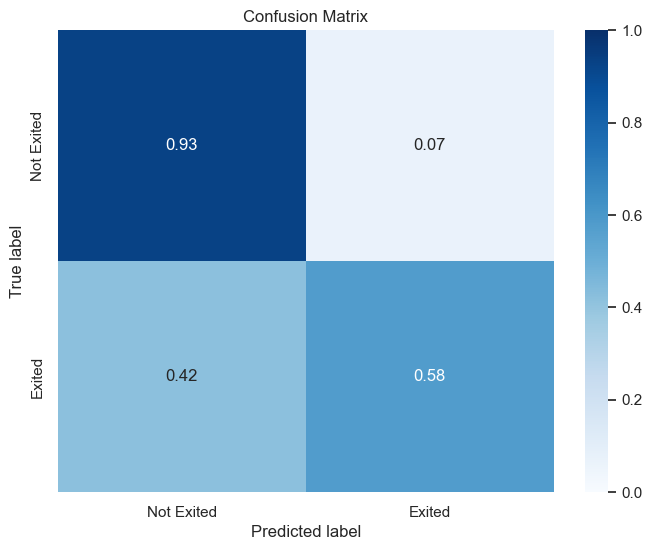

In [21]:
# Calculate confusion matrix
cm = confusion_matrix(y_test, y_test_pred, normalize='true')
plot_confusion_matrix(cm, classes=["Not Exited", "Exited"])

# Visualizing the tree

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/xgboost/plotting.py:267: FutureWarning: The `num_trees` parameter is deprecated, use `tree_idx` insetad. 
  warnings.warn(


Render error: failed to execute PosixPath('dot'), make sure the Graphviz executables are on your systems' PATH


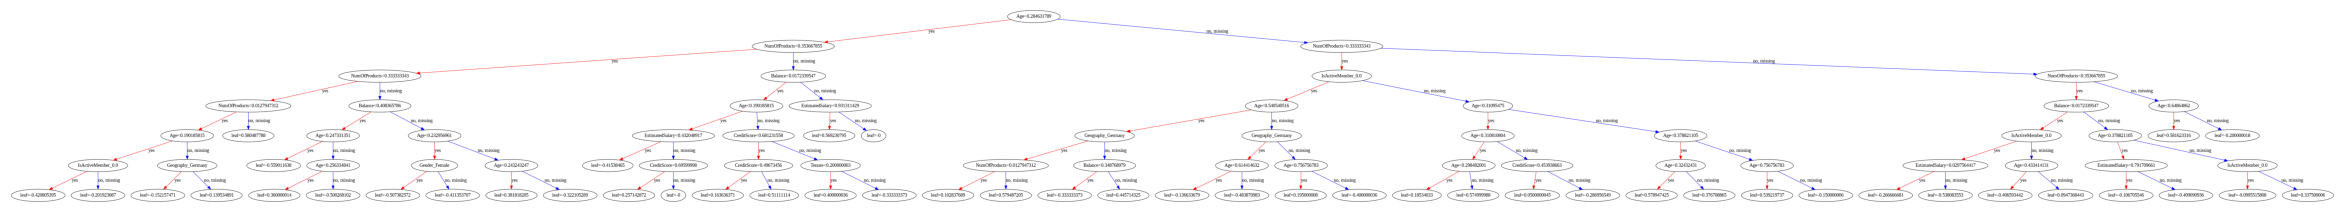

In [36]:
from PIL import Image
import xgboost as xgb
import matplotlib.pyplot as plt

dot_data = xgb.to_graphviz(model, num_trees=0)
output_file = "xgboost_tree"

# Try rendering and catch errors
try:
    dot_data.render(output_file, format="png", view=False)
except Exception as e:
    print("Render error:", e)

# Check if file exists before opening
import os
if os.path.exists(f"{output_file}.png"):
    img = Image.open(f"{output_file}.png")
    plt.figure(figsize=(30, 30))
    plt.imshow(img)
    plt.axis("off")
    plt.show()
else:
    print("PNG file was not created. Check Graphviz installation and PATH.")

Training Accuracy: 0.77
Testing Accuracy: 0.81


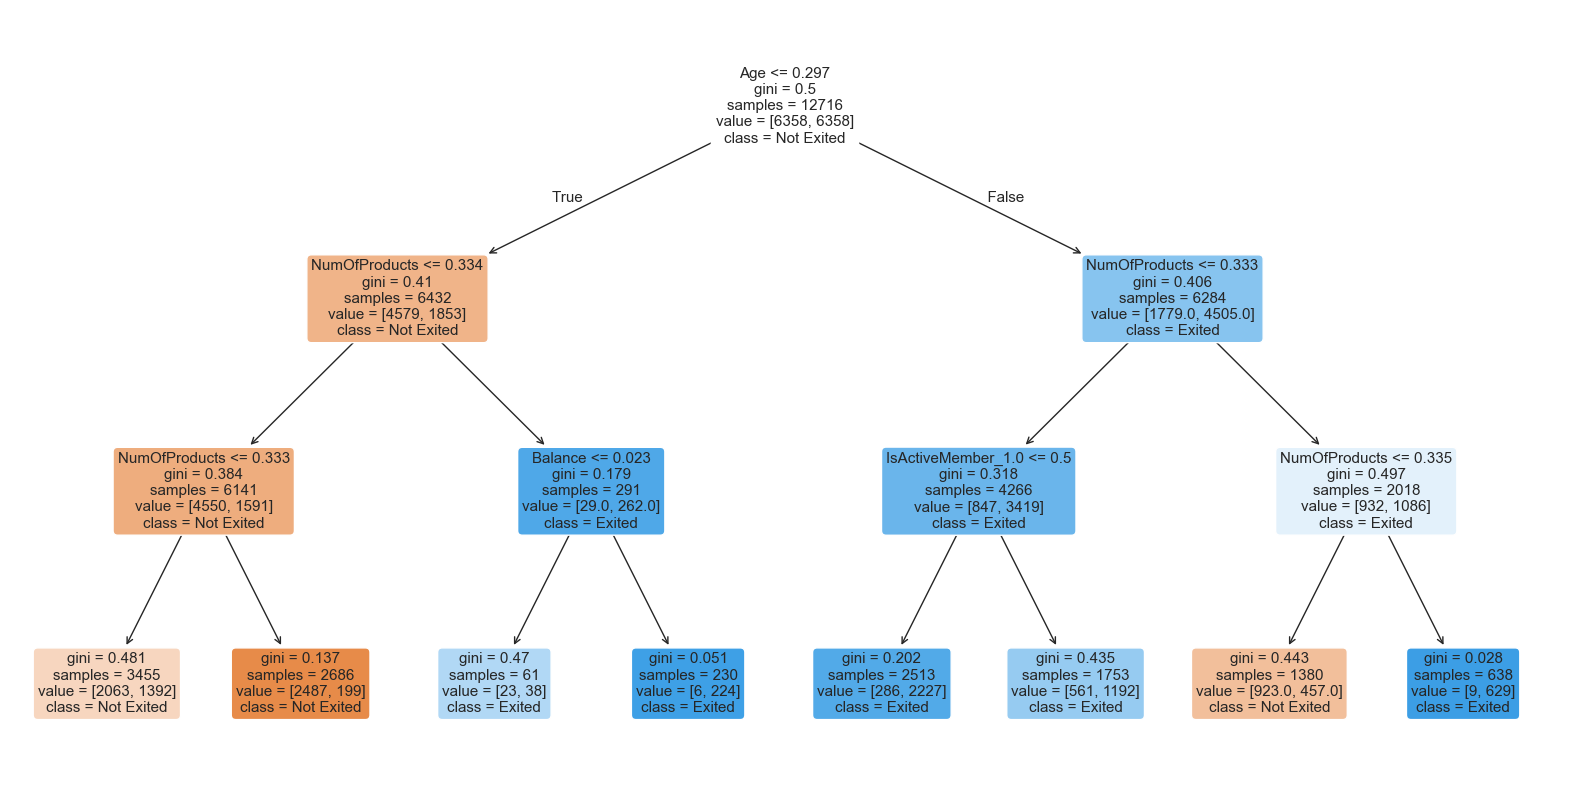

In [48]:
from sklearn import tree
import matplotlib.pyplot as plt

# Train a Decision Tree Classifier
dt = DecisionTreeClassifier(random_state=42, max_depth=3)  # Adjust max_depth for simplicity
dt.fit(X_train_resampled, y_train_resampled)

# Predictions and evaluation
y_train_pred = dt.predict(X_train_resampled)
y_test_pred = dt.predict(X_test)

train_accuracy = accuracy_score(y_train_resampled, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

print(f"Training Accuracy: {train_accuracy:.2f}")
print(f"Testing Accuracy: {test_accuracy:.2f}")

plt.figure(figsize=(20, 10))
tree.plot_tree(
    dt,
    feature_names=new_raw_data.drop("Exited", axis=1).columns,
    class_names=["Not Exited", "Exited"],
    filled=True,
    rounded=True
)
plt.show()

In [ ]:
#optimize our model using RandomizedSearchCV to find the best hyperparameters for XGBoost. This improves accuracy and prediction reliability.
from sklearn.model_selection import RandomizedSearchCV

# Define the parameter grid for RandomizedSearchCV
param_grid = {
    "n_estimators": [100, 200, 300],  # Number of trees
    "max_depth": [3, 5, 7, 10],      # Maximum depth of a tree
    "learning_rate": [0.01, 0.05, 0.1, 0.2],  # Step size shrinkage
    "subsample": [0.6, 0.8, 1.0],    # Fraction of samples to grow trees
    "colsample_bytree": [0.6, 0.8, 1.0],  # Fraction of features for tree building
    "gamma": [0, 1, 5],              # Minimum loss reduction for split
    "reg_lambda": [1, 10, 50],       # L2 regularization term
}

# Initialize the base XGBoost classifier
xgb_base = XGBClassifier(use_label_encoder=False, eval_metric='auc', random_state=42)

# Apply RandomizedSearchCV
random_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_grid,
    n_iter=50,  # Number of parameter settings sampled
    scoring="f1",
    cv=3,  # 3-fold cross-validation
    random_state=42,
    verbose=1,
    n_jobs=-1  # Use all available cores
)

# Fit RandomizedSearchCV
random_search.fit(X_train_resampled, y_train_resampled)

# Get the best parameters and model
best_params = random_search.best_params_
print("Best Hyperparameters:", best_params)

# Re-train the model with the best hyperparameters
best_model = random_search.best_estimator_
best_model.fit(X_train_resampled, y_train_resampled)

# Predictions
y_train_pred = best_model.predict(X_train_resampled)
y_test_pred = best_model.predict(X_test)
all_df_predict = best_model.predict(X)
all_df_predict_prob = best_model.predict_proba(X)

# Training and Testing Accuracy
train_accuracy = accuracy_score(y_train_resampled, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

print(f"Training Accuracy: {train_accuracy:.2f}")
print(f"Testing Accuracy: {test_accuracy:.2f}")

# Feature Importance
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": best_model.feature_importances_
}).sort_values(by="Importance", ascending=False)
feature_importance
# metrics: https://scikit-learn.org/1.5/modules/model_evaluation.html#scoring-parameter

Fitting 3 folds for each of 50 candidates, totalling 150 fits


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/xgboost/training.py:183: UserWarning: [13:19:23] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/xgboost/training.py:183: UserWarning: [13:19:23] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/xgboost/training.py:183: UserWarning: [13:19:23] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/xgboost/training.py:183: UserWarning: [13:19:23] WARN

Best Hyperparameters: {'subsample': 1.0, 'reg_lambda': 10, 'n_estimators': 200, 'max_depth': 10, 'learning_rate': 0.05, 'gamma': 0, 'colsample_bytree': 0.8}


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/xgboost/training.py:183: UserWarning: [13:19:28] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Training Accuracy: 0.94
Testing Accuracy: 0.86


,Feature,Importance
4,NumOfProducts,0.496863
1,Age,0.099745
13,IsActiveMember_0.0,0.090525
7,Geography_Germany,0.055676
14,IsActiveMember_1.0,0.052702
2,Tenure,0.040790
3,Balance,0.028992
9,Gender_Female,0.025817
10,Gender_Male,0.020958
8,Geography_Spain,0.018918


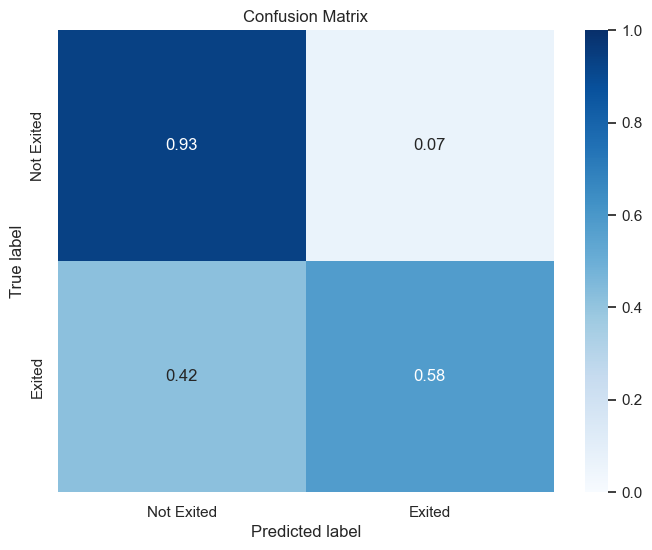

In [41]:
# Calculate confusion matrix
cm = confusion_matrix(y_test, y_test_pred, normalize='true')
plot_confusion_matrix(cm, classes=["Not Exited", "Exited"])

# Storing Models and Results

In [42]:
# Adding the predictions back to the original dataset
raw['Exited Prediction'] = all_df_predict
raw['Exited Prediction Probability'] = all_df_predict_prob[:,1]

# Expoprting all the data with predictions
raw.to_excel("bank_churn_data.xlsx")

In [43]:
# Storing the Feature Importances
feature_importance['Feature Importance Score'] = feature_importance['Importance'].round(4)
feature_importance.to_excel("feature_importance.xlsx")

In [ ]:
# Save the best_model to a file(we store our trained model and scaler using Pickle, so we can reuse them later without retraining)
import pickle

with open('best_model.pkl', 'wb') as file:
    pickle.dump(best_model, file)

print("Model saved successfully!")

# saving the scaler
with open('scaler.pkl', 'wb') as file:
    pickle.dump(scaler, file)

Model saved successfully!
